In [ ]:
import pandas as pd
import numpy as np
import sqlite3
import json
import re
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
import seaborn as sns
import scipy.stats as stats
from scipy.stats import chi2_contingency


# 정형 데이터 미니퀘스트 1번

data = {
    '이름': ['김철수', '이영희', '박민수', '최지현', '홍길동'],
    '나이': [25, 30, 35, 28, 40],
    '직업': ['개발자', '마케터', '개발자', '디자이너', 'CEO'],
    '연봉': [4000, 3500, 5000, 4200, 10000],
    '가입일': ['2020-05-21', '2019-07-15', '2021-01-10', '2018-11-03', '2017-09-27']
}

df = pd.DataFrame(data)
# df.to_csv('data.csv', index=False)

print(df.info())
print(df.head())
print(df.describe())
print(df.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   이름      5 non-null      object
 1   나이      5 non-null      int64 
 2   직업      5 non-null      object
 3   연봉      5 non-null      int64 
 4   가입일     5 non-null      object
dtypes: int64(2), object(3)
memory usage: 332.0+ bytes
None
    이름  나이    직업     연봉         가입일
0  김철수  25   개발자   4000  2020-05-21
1  이영희  30   마케터   3500  2019-07-15
2  박민수  35   개발자   5000  2021-01-10
3  최지현  28  디자이너   4200  2018-11-03
4  홍길동  40   CEO  10000  2017-09-27
             나이           연봉
count   5.00000      5.00000
mean   31.60000   5340.00000
std     5.94138   2660.45109
min    25.00000   3500.00000
25%    28.00000   4000.00000
50%    30.00000   4200.00000
75%    35.00000   5000.00000
max    40.00000  10000.00000
Index(['이름', '나이', '직업', '연봉', '가입일'], dtype='object')


In [ ]:
# 정형 데이터 미니퀘스트 2번

data = {
    '이름': ['김철수', '이영희', '박민수', '최지현', '홍길동', '정지훈', '이지은'],
    '나이': [25, 30, 35, 28, 40, 50, 22],
    '직업': ['개발자', '마케터', '개발자', '디자이너', 'CEO', '디자이너', '마케터'],
    '연봉': [4000, 3500, 5000, 4200, 10000, 4600, 3300],
    '가입일': ['2020-05-21', '2019-07-15', '2021-01-10', '2018-11-03', '2017-09-27', '2016-04-11', '2022-03-19']
}

df = pd.DataFrame(data)

print(df[(df['나이'] >= 30) & (df['연봉'] <= 5000)])

    이름  나이    직업    연봉         가입일
1  이영희  30   마케터  3500  2019-07-15
2  박민수  35   개발자  5000  2021-01-10
5  정지훈  50  디자이너  4600  2016-04-11


In [ ]:
# 정형 데이터 미니퀘스트 3번

data = {
    '이름': ['김철수', '이영희', '박민수', '최지현', '홍길동', '정지훈', '이지은'],
    '나이': [25, 30, 35, 28, 40, 50, 22],
    '직업': ['개발자', '마케터', '개발자', '디자이너', 'CEO', '디자이너', '마케터'],
    '연봉': [4000, 3500, 5000, 4200, 10000, 4600, 3300],
    '가입일': ['2020-05-21', '2019-07-15', '2021-01-10', '2018-11-03', '2017-09-27', '2016-04-11', '2022-03-19']
}

df = pd.DataFrame(data)

df['가입일'] = pd.to_datetime(df['가입일'])

df.loc[df['가입일'] < '2019-01-01', '연봉'] *= 1.1

print(df['연봉'].mean())

5211.428571428572


In [ ]:
# 비정형 데이터 미니퀘스트 1번
import json

data = '''
[
    {"이름": "김철수", "나이": 25, "직업": "개발자", "연봉": 4000},
    {"이름": "이영희", "나이": 30, "직업": "마케터", "연봉": 3500},
    {"이름": "박민수", "나이": 35, "직업": "디자이너", "연봉": 4200}
]
'''

json_data = json.loads(data)

df = pd.DataFrame(json_data)

print(df)


    이름  나이    직업    연봉
0  김철수  25   개발자  4000
1  이영희  30   마케터  3500
2  박민수  35  디자이너  4200


In [ ]:
# 비정형 데이터 미니퀘스트 2번
import re

text = "안녕하세요!!! 저는 AI 모델-입니다. 12345 데이터를   정리해 보겠습니다."

clean_text = re.sub(r"[^가-힣0-9\s]", "", text)
clean_text = re.sub(r"\s+", " ", clean_text).strip()

print(clean_text)

안녕하세요 저는 모델입니다 12345 데이터를 정리해 보겠습니다


In [ ]:
# 비정형 데이터 미니퀘스트 3번
from collections import Counter
import pandas as pd

text = "자연어 처리는 재미있다. 파이썬과 pandas를 활용하면 편리하다. 데이터 분석은 흥미롭다."

sentences = text.split(". ")

df = pd.DataFrame({'문장' : sentences})

df['단어 수'] = df['문장'].str.split().str.len()

print(df)


                       문장  단어 수
0            자연어 처리는 재미있다     3
1  파이썬과 pandas를 활용하면 편리하다     4
2           데이터 분석은 흥미롭다.     3


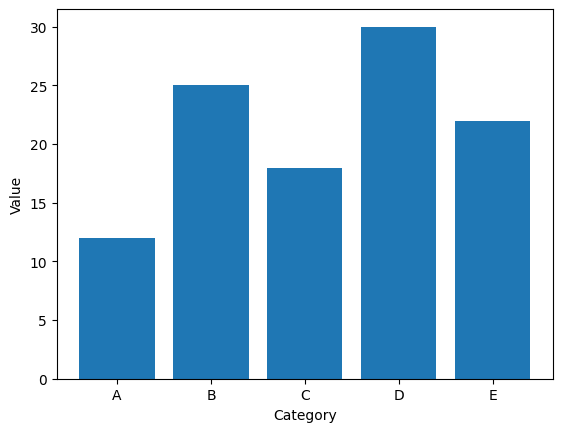

In [ ]:
# 막대 그래프 미니퀘스트 1번
import matplotlib.pyplot as plt

categories = ['A', 'B', 'C', 'D', 'E']
values = [12, 25, 18, 30, 22]

plt.bar(categories, values)
plt.xlabel('Category')
plt.ylabel('Value')

plt.show()

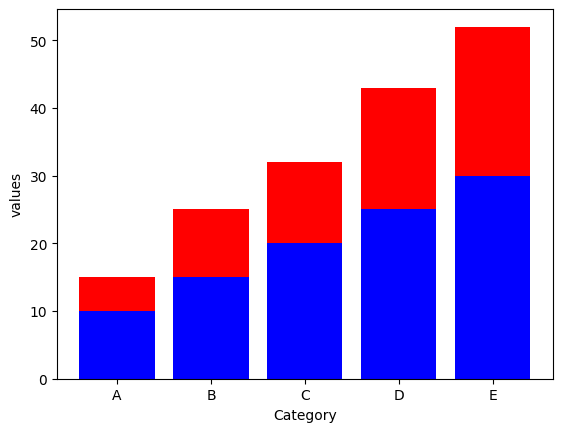

In [ ]:
# 막대 그래프 미니퀘스트 2번

categories = ['A', 'B', 'C', 'D', 'E']
values_2023 = [10, 15, 20, 25, 30]
values_2024 = [5, 10, 12, 18, 22]

x = np.arange(len(categories))

plt.bar(x, values_2023, color = 'blue')
plt.bar(x, values_2024, color = 'red', bottom = values_2023)

plt.xticks(x, categories)

plt.xlabel('Category')
plt.ylabel("values")

plt.show()

Text(0, 0.5, 'Performance')

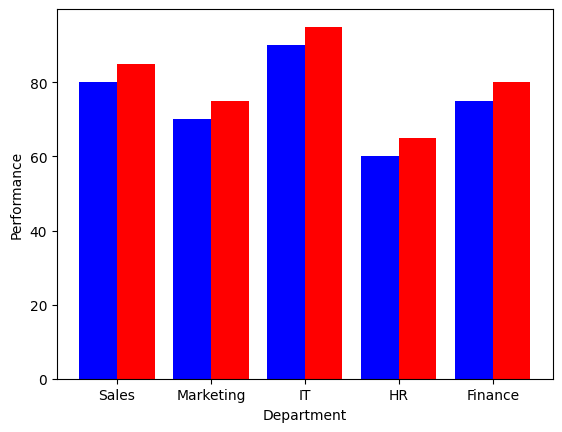

In [ ]:
# 막대 그래프 미니퀘스트 3번

departments = ['Sales', 'Marketing', 'IT', 'HR', 'Finance']
performance_2023 = [80, 70, 90, 60, 75]
performance_2024 = [85, 75, 95, 65, 80]

x = np.arange(len(departments))

plt.bar(x - 0.2, performance_2023, width = 0.4, color = 'blue')
plt.bar(x + 0.2, performance_2024, width = 0.4, color = 'red')

plt.xticks(x, departments)

plt.xlabel('Department')
plt.ylabel('Performance')

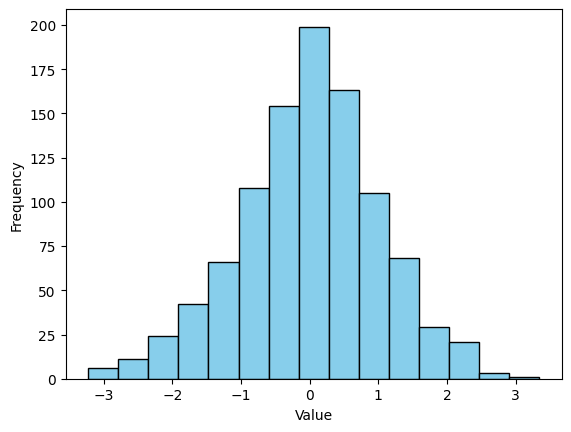

In [ ]:
# 히스토그램 미니퀘스트 1번

data = np.random.randn(1000)

plt.hist(data, bins = 15, color = 'skyblue', edgecolor = 'black')

plt.xlabel('Value')
plt.ylabel('Frequency')

plt.show()

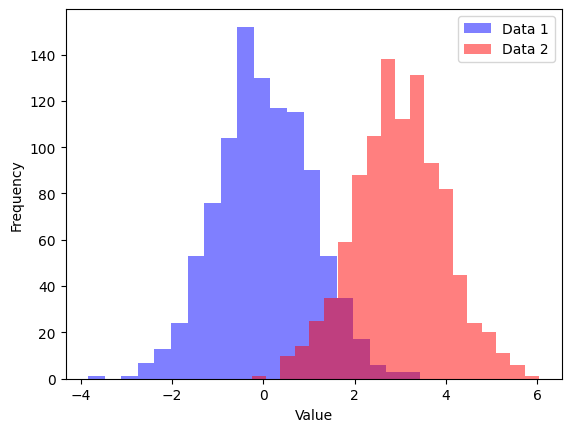

In [ ]:
# 히스토그램 미니퀘스트 2번

# 첫 번째 데이터셋 (평균 0, 표준편차 1)
data1 = np.random.randn(1000)

# 두 번째 데이터셋 (평균 3, 표준편차 1)
data2 = np.random.randn(1000) + 3

plt.hist(data1, bins=20, alpha=0.5, color='blue', label='Data 1')
plt.hist(data2, bins=20, alpha=0.5, color='red', label='Data 2')

plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()
plt.show()

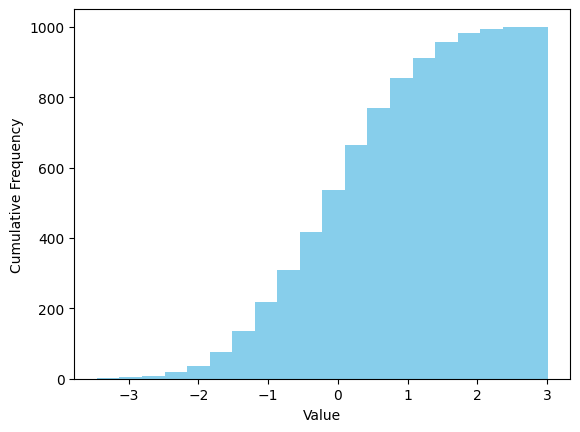

In [ ]:
# 히스토그램 미니퀘스트 3번

# 정규 분포를 따르는 1000개의 데이터 생성
data = np.random.randn(1000)

plt.hist(data, bins=20, cumulative=True, color='skyblue')

plt.xlabel('Value')
plt.ylabel('Cumulative Frequency')
plt.show()


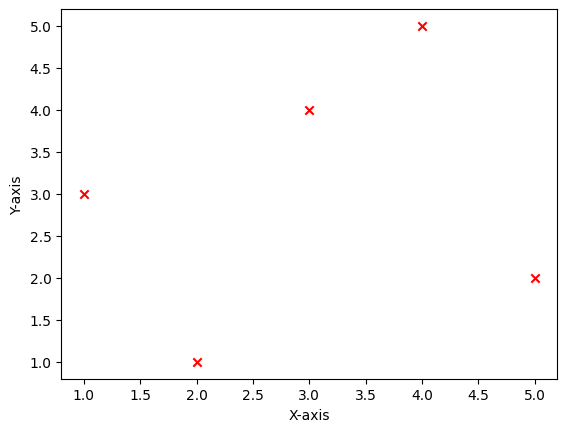

In [ ]:
# 산점도 미니퀘스트 1번

# 데이터 생성
x = [1, 2, 3, 4, 5]
y = [3, 1, 4, 5, 2]

plt.scatter(x,y, color='red', marker='x')

plt.xlabel('X-axis')
plt.ylabel('Y-axis')

plt.show()

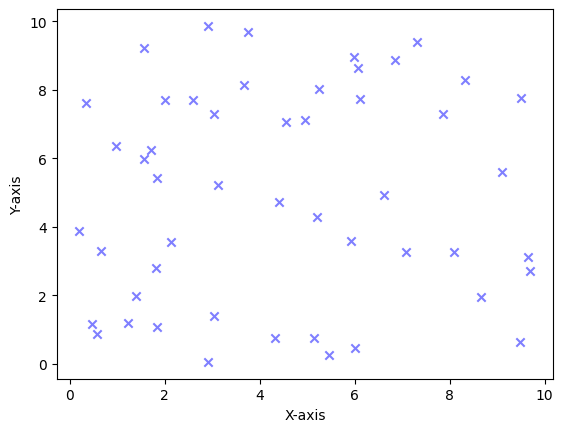

In [ ]:
# 산점도 미니퀘스트 2번

np.random.seed(42)
x = np.random.rand(50) * 10  # 0~10 범위의 난수 50개
y = np.random.rand(50) * 10  # 0~10 범위의 난수 50개

plt.scatter(x,y, color='blue', marker='x', alpha=0.5)

plt.xlabel('X-axis')
plt.ylabel('Y-axis')

plt.show()

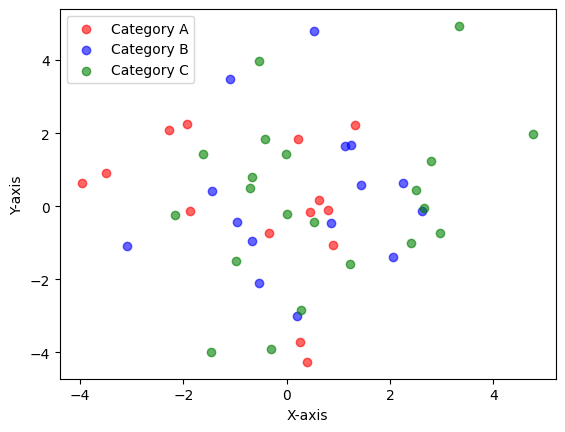

In [ ]:
# 산점도 미니퀘스트 3번

np.random.seed(10)
x = np.random.randn(50) * 2
y = np.random.randn(50) * 2
categories = np.random.choice(['A', 'B', 'C'], size=50)
color = {'A' : 'red', 'B' : 'blue', 'C' : 'green'}

for cat in np.unique(categories):
  idx = categories == cat

  plt.scatter(x[idx], y[idx], color=color[cat],label=f'Category {cat}',alpha=0.6)

plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend()
plt.show()

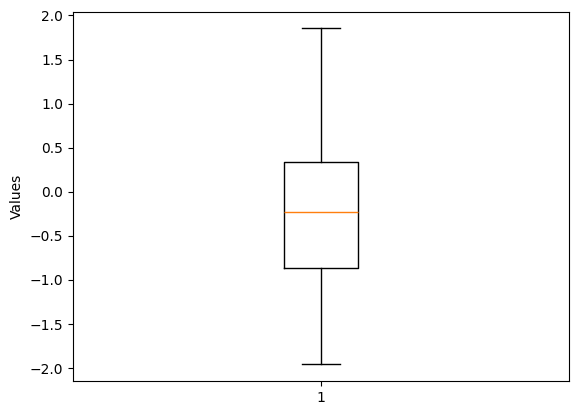

In [ ]:
# 박스플롯 미니퀘스트 1번

# 정규분포를 따르는 난수 50개 생성
np.random.seed(42)
data = np.random.randn(50)

plt.boxplot(data)

plt.ylabel('Values')

plt.show()


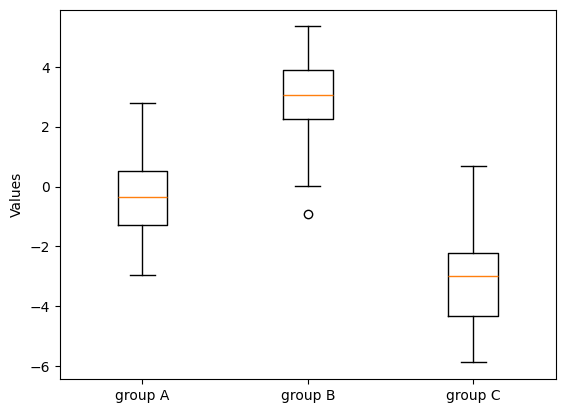

In [ ]:
# 박스플롯 미니퀘스트 2번

# 랜덤 데이터 생성 (각 그룹별 평균 다르게 설정)
np.random.seed(42)
group_a = np.random.randn(50) * 1.5  # 표준편차 1.5, 평균 0
group_b = np.random.randn(50) * 1.5 + 3  # 표준편차 1.5, 평균 3
group_c = np.random.randn(50) * 1.5 - 3  # 표준편차 1.5, 평균 -3

plt.boxplot([group_a, group_b, group_c], tick_labels=['group A','group B', 'group C'])

plt.ylabel('Values')

plt.show()

/tmp/ipykernel_872/3333393943.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([group_x, group_y], labels=['Group X', 'Group Y'], patch_artist=True, boxprops=dict(facecolor='skyblue', color='red'), flierprops=dict(marker='x', markerfacecolor='red'))


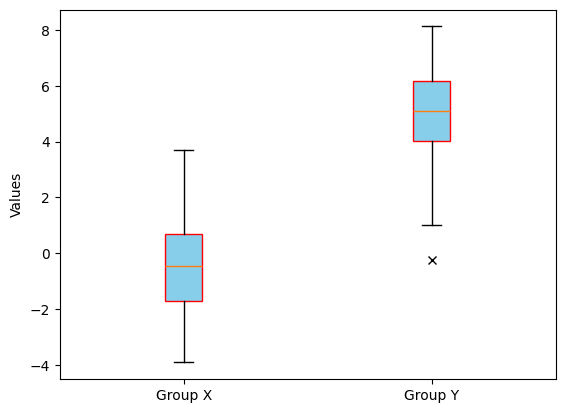

In [ ]:
# 박스플롯 미니퀘스트 3번

# 랜덤 데이터 생성 (두 그룹의 평균 다르게 설정)
np.random.seed(42)
group_x = np.random.randn(50) * 2  # 표준편차 2, 평균 0
group_y = np.random.randn(50) * 2 + 5  # 표준편차 2, 평균 5

plt.boxplot([group_x, group_y], labels=['Group X', 'Group Y'], patch_artist=True, boxprops=dict(facecolor='skyblue', color='red'), flierprops=dict(marker='x', markerfacecolor='red'))

plt.ylabel('Values')

plt.show()

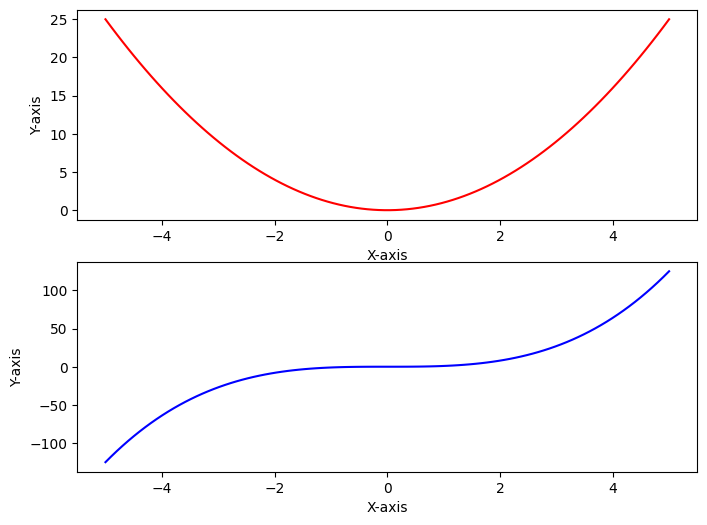

In [ ]:
# 고급 다중 그래프 미니퀘스트 1번

# 데이터 생성
x = np.linspace(-5, 5, 100)
y1 = x ** 2  # x의 제곱
y2 = x ** 3  # x의 세제곱

fig,axes = plt.subplots(nrows=2, ncols= 1, figsize=(8,6))

axes[0].plot(x, y1, color='r', label='x^2')
axes[0].set_xlabel('X-axis')
axes[0].set_ylabel('Y-axis')

axes[1].plot(x, y2, color='b', label='x^3')
axes[1].set_xlabel('X-axis')
axes[1].set_ylabel('Y-axis')

plt.show()

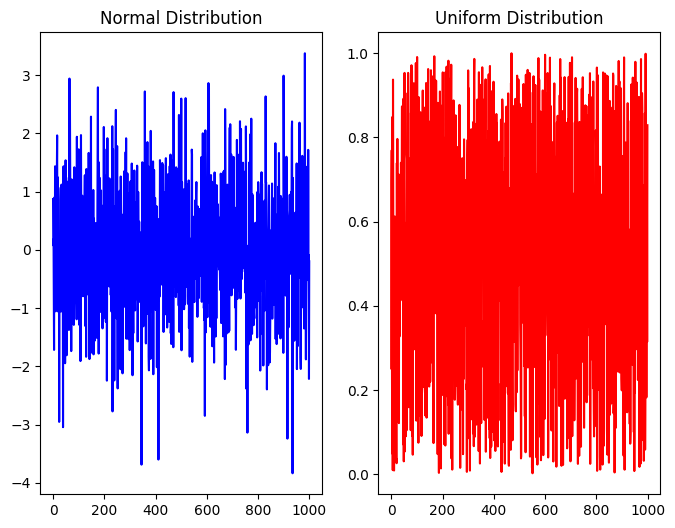

In [ ]:
# 고급 다중 그래프 미니퀘스트 2번

# 데이터 생성
normal_data = np.random.randn(1000)  # 정규 분포 난수 1000개
uniform_data = np.random.rand(1000)  # 균등 분포 난수 1000개

fig, axes = plt.subplots(1,2 , sharex=True, figsize=(8,6))

axes[0].plot(normal_data, color='b', label='Normal Distribution')
axes[0].set_title('Normal Distribution')

axes[1].plot(uniform_data, color='r', label='Uniform Distribution')
axes[1].set_title('Uniform Distribution')

plt.show()

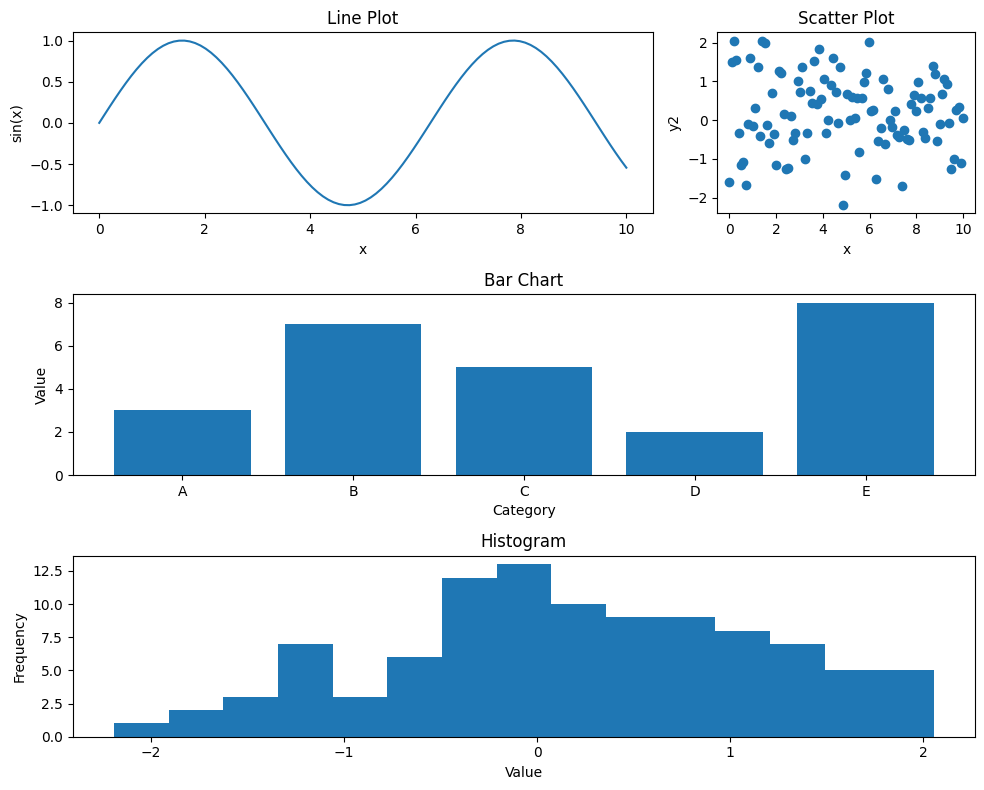

In [ ]:
# 고급 다중 그래프 미니퀘스트 3번

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# 데이터 생성
x = np.linspace(0, 10, 100)
y1 = np.sin(x)
y2 = np.random.randn(100)
categories = ['A', 'B', 'C', 'D', 'E']
values = [3, 7, 5, 2, 8]

fig = plt.figure(figsize=(10, 8))
gs = GridSpec(3, 3, figure=fig)

ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(x, y1)
ax1.set_title("Line Plot")
ax1.set_xlabel("x")
ax1.set_ylabel("sin(x)")

ax2 = fig.add_subplot(gs[0, 2])
ax2.scatter(x, y2)
ax2.set_title("Scatter Plot")
ax2.set_xlabel("x")
ax2.set_ylabel("y2")

ax3 = fig.add_subplot(gs[1, :])
ax3.bar(categories, values)
ax3.set_title("Bar Chart")
ax3.set_xlabel("Category")
ax3.set_ylabel("Value")

ax4 = fig.add_subplot(gs[2, :])
ax4.hist(y2, bins=15)
ax4.set_title("Histogram")
ax4.set_xlabel("Value")
ax4.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [ ]:
# 벤다이어그램 미니퀘스트 1번

# 두 개의 과일 집합 정의
set_A = {"사과", "바나나", "체리", "망고"}
set_B = {"바나나", "망고", "포도", "수박"}

only_A = set_A - set_B
only_B = set_B - set_A

print(only_A)
print(only_B)

{'사과', '체리'}
{'포도', '수박'}


In [ ]:
# 벤다이어그램 미니퀘스트 2번

# 세 개의 과일 집합 정의
set_A = {"사과", "바나나", "체리", "망고"}
set_B = {"바나나", "망고", "포도", "수박"}
set_C = {"망고", "수박", "딸기", "오렌지"}

only_A = set_A - (set_B | set_C)
only_B = set_B - (set_A | set_C)
only_C = set_C - (set_A | set_B)

intersection = set_A & set_B & set_C

print(len(only_A))
print(len(only_B))
print(len(only_C))
print(len(intersection))

2
1
2
1


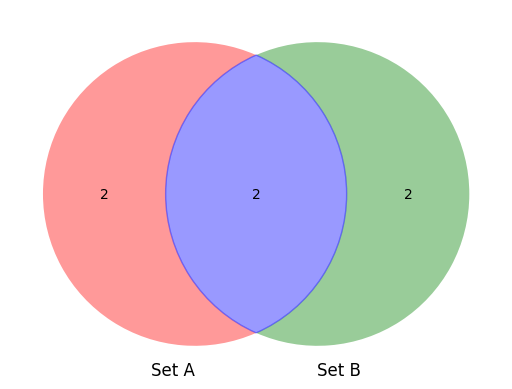

In [ ]:
# 벤다이어그램 미니퀘스트 3번

# 두 개의 집합 정의
set_A = {"사과", "바나나", "체리", "망고"}
set_B = {"바나나", "망고", "포도", "수박"}

diagram = venn2([set_A,set_B], set_labels = ('Set A', 'Set B'))

if len(set_A & set_B) >= 2:
  diagram.get_patch_by_id('11').set_color('blue')

plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52852 (\N{HANGUL SYLLABLE KA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53580 (\N{HANGUL SYLLABLE TE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


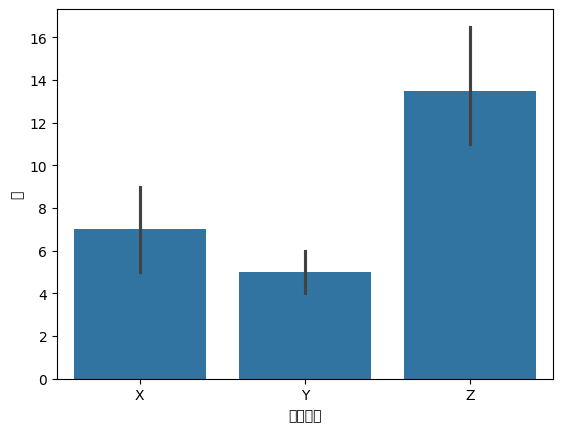

In [ ]:
# 범주형 데이터 미니퀘스트 1번

# 샘플 데이터 생성
data = pd.DataFrame({
    "카테고리": ["X", "X", "Y", "Y", "Z", "Z", "Z", "X", "Y", "Z"],
    "값": [5, 9, 4, 6, 12, 10, 14, 7, 5, 18]
})

sns.barplot(x='카테고리', y='값', data=data)

plt.show()

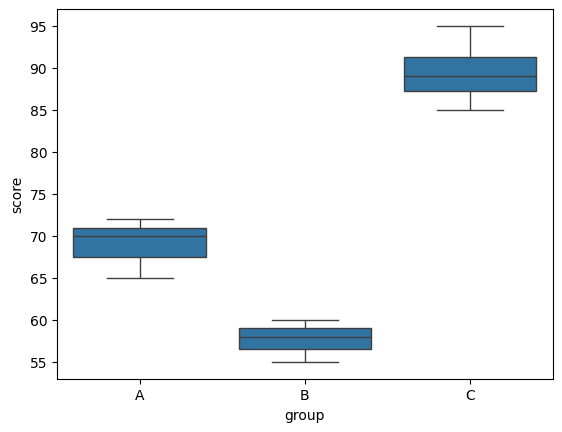

In [ ]:
# 범주형 데이터 미니퀘스트 2번

# 샘플 데이터 생성
data = pd.DataFrame({
    "group": ["A", "A", "B", "B", "C", "C", "C", "A", "B", "C"],
    "score": [65, 70, 55, 60, 90, 85, 95, 72, 58, 88]
})

sns.boxplot(x="group", y="score", data=data)

plt.show()

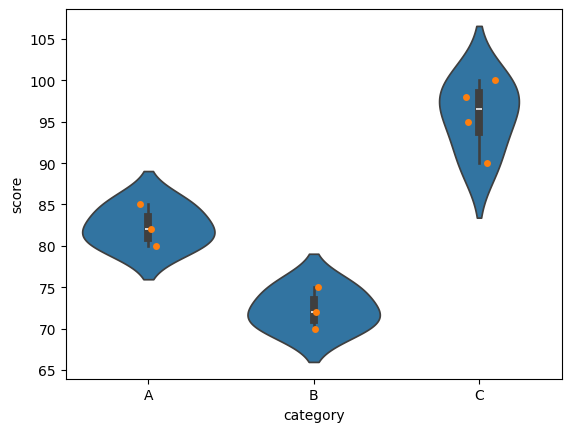

In [ ]:
# 범주형 데이터 미니퀘스트 3번

# 샘플 데이터 생성
data = pd.DataFrame({
    "category": ["A", "A", "B", "B", "C", "C", "C", "A", "B", "C"],
    "score": [80, 85, 70, 75, 95, 90, 100, 82, 72, 98]
})

sns.violinplot(x="category", y="score", data=data)
sns.stripplot(x="category", y="score", data=data, jitter=True)

plt.show()

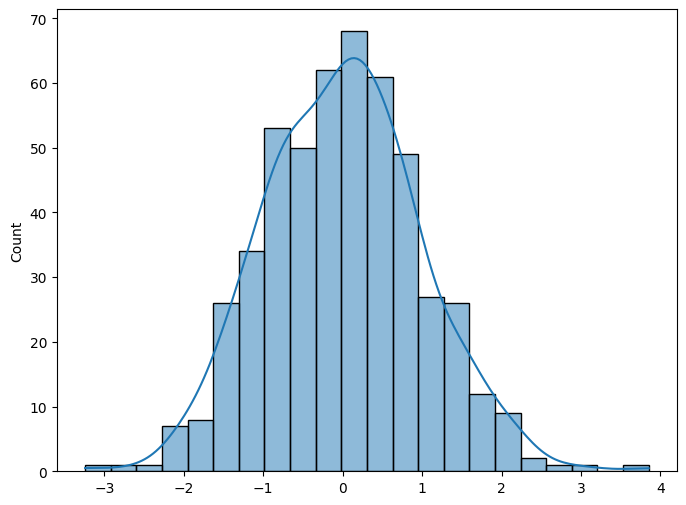

In [ ]:
# 연속형 데이터 미니퀘스트 1번

# 정규 분포를 따르는 데이터 생성
np.random.seed(42)
data = np.random.randn(500)

plt.figure(figsize=(8,6))
sns.histplot(data, kde=True)

plt.show()

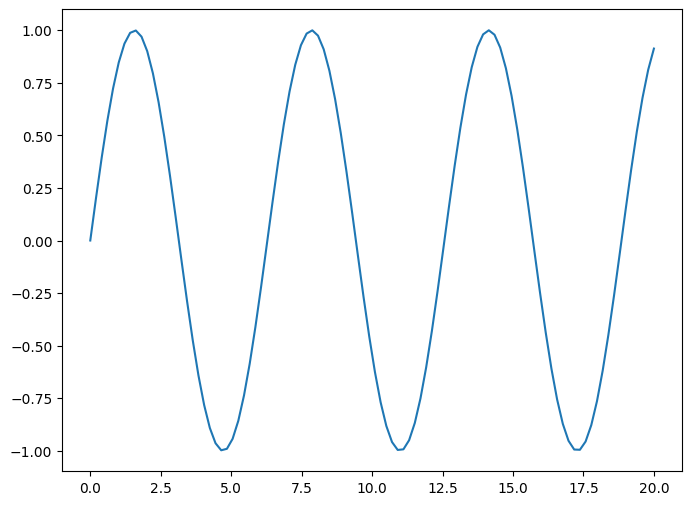

In [ ]:
# 연속형 데이터 미니퀘스트 2번

# X 값 생성 (0부터 20까지 100개의 균등한 값)
x = np.linspace(0, 20, 100)
y = np.sin(x)

plt.figure(figsize=(8, 6))
sns.lineplot(x=x, y=y)

plt.show()

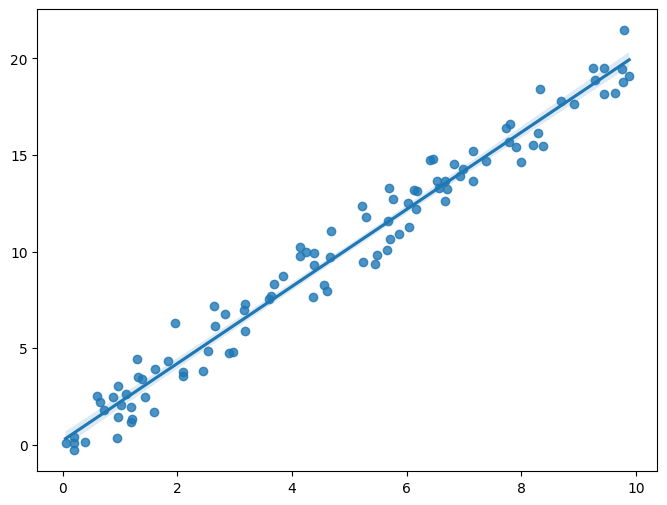

In [ ]:
# 연속형 데이터 미니퀘스트 3번

# 난수 생성 (재현 가능성 유지)
np.random.seed(0)
x = np.random.rand(100) * 10  # 0~10 사이 난수
y = 2 * x + np.random.randn(100)  # x와 비례하는 관계, 약간의 변동 추가

plt.figure(figsize=(8, 6))
sns.regplot(x=x, y=y)

plt.show()



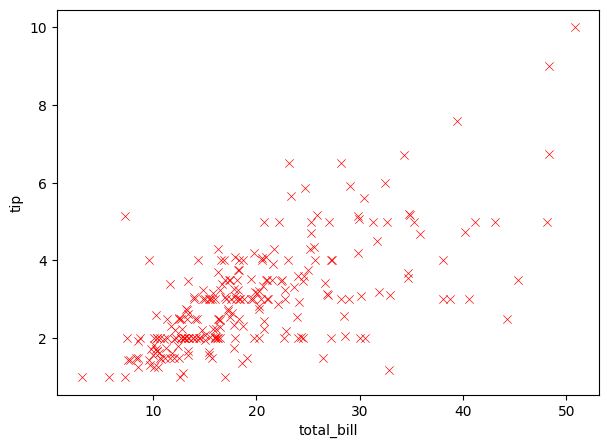

In [ ]:
# 관계형 데이터 미니퀘스트 1번

# 예제 데이터 로드 (Seaborn 내장 데이터셋: tips)
tips = sns.load_dataset("tips")

plt.figure(figsize=(7, 5))
sns.scatterplot(x="total_bill", y="tip", data=tips, color="red", marker='x')

plt.show()

<Axes: xlabel='total_bill', ylabel='tip'>

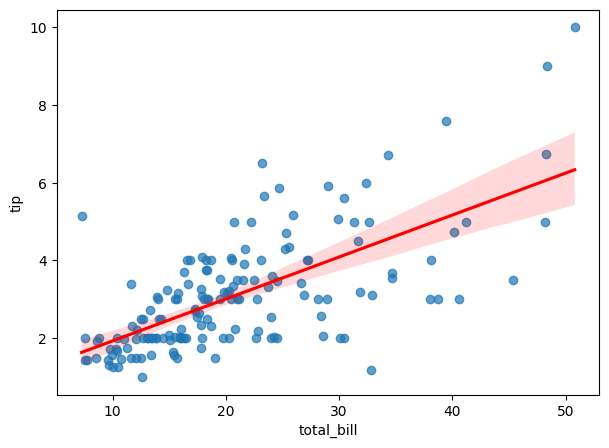

In [ ]:
# 관계형 데이터 미니퀘스트 2번

tips = sns.load_dataset("tips")

tips = tips[tips['sex'] == "Male"]

plt.figure(figsize=(7, 5))
sns.regplot(x="total_bill", y="tip", data=tips, scatter_kws={'alpha':0.7}, line_kws={'color':'red'})

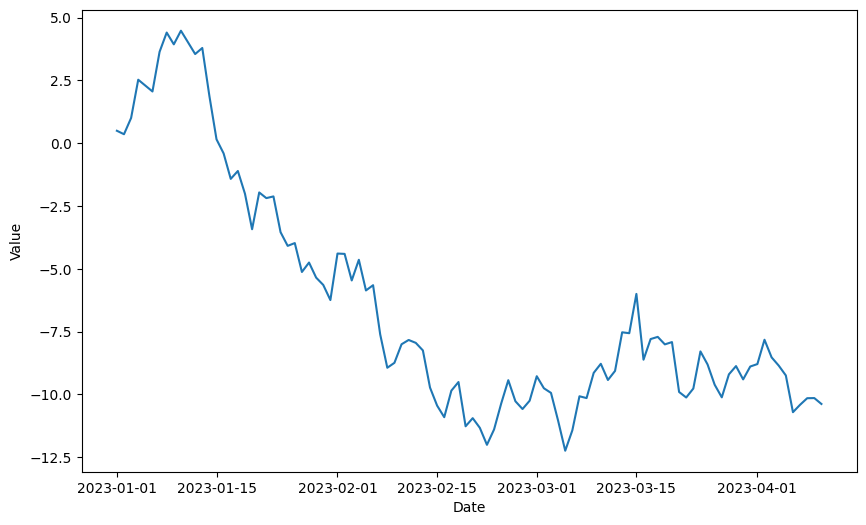

In [ ]:
# 시계열 데이터 미니퀘스트 1번

# 시계열 데이터 생성
np.random.seed(42)
date_range = pd.date_range(start="2023-01-01", periods=100, freq="D")  # 100일간의 날짜 생성
values = np.cumsum(np.random.randn(100))  # 랜덤 값의 누적합

df = pd.DataFrame({"Date": date_range, "Value": values})

plt.figure(figsize=(10, 6))
sns.lineplot(x="Date", y="Value", data=df)

plt.show()

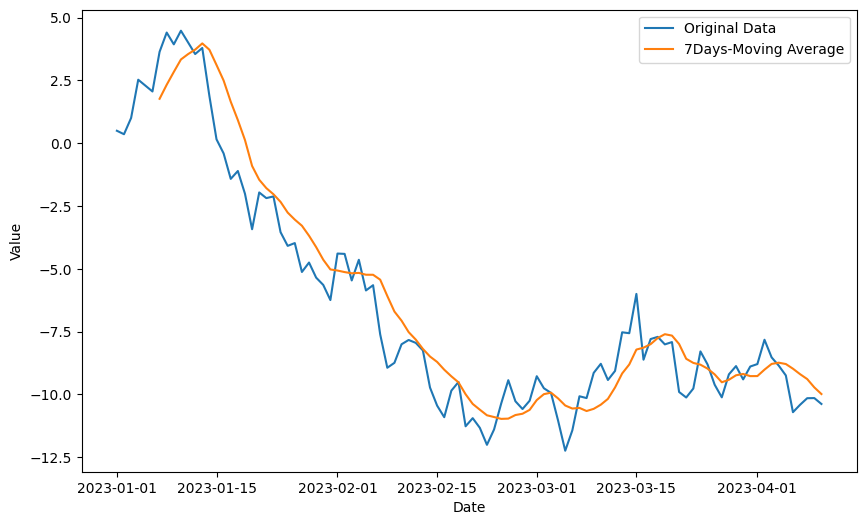

In [ ]:
# 시계열 데이터 미니퀘스트 2번

df["Moving_Avg"] = df["Value"].rolling(window=7).mean()

plt.figure(figsize=(10, 6))
sns.lineplot(x="Date", y="Value", data=df, label="Original Data")
sns.lineplot(x="Date", y="Moving_Avg", data=df, label="7Days-Moving Average")

plt.show()

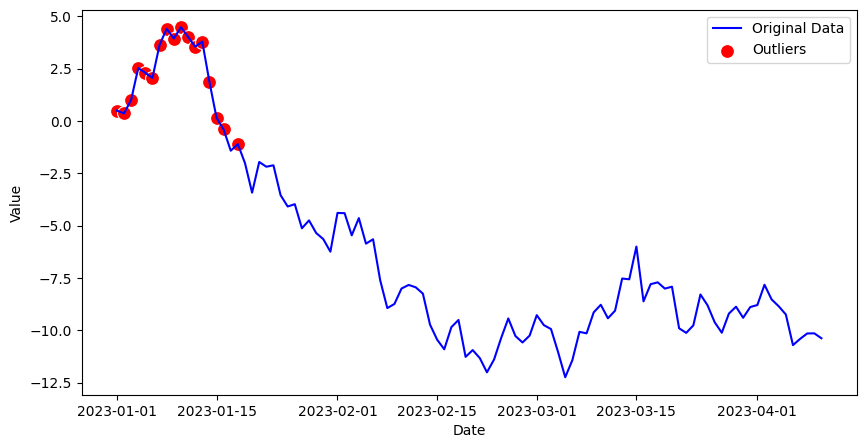

In [ ]:
# 시계열 데이터 미니퀘스트 3번

Q1 = df["Value"].quantile(0.25)
Q3 = df["Value"].quantile(0.75)
IQR = Q3 - Q1
k = 0.5
lower_bound = Q1 - k * IQR
upper_bound = Q3 + k * IQR

df["Outlier"] = (df["Value"] < lower_bound) | (df["Value"] > upper_bound)

outliers = df[df["Outlier"]]

plt.figure(figsize=(10, 5))
sns.lineplot(x="Date", y="Value", data=df, label="Original Data", color="blue")
sns.scatterplot(x="Date", y="Value", data=outliers, color="red", label="Outliers", s=100)

plt.show()

In [ ]:
# 리샘플링 미니퀘스트 1번

# 3시간 간격의 시계열 데이터 생성 (2024년 1월 1일부터 5일까지)
date_rng = pd.date_range(start="2024-01-01", end="2024-01-05", freq="3h")


df = pd.DataFrame({
    "datetime": date_rng,
    "value": np.random.randint(10, 100, size=len(date_rng))
})

df.set_index("datetime", inplace=True)

df_daily = df.resample("D").mean()

print(df_daily.head())

             value
datetime          
2024-01-01  38.375
2024-01-02  61.000
2024-01-03  65.125
2024-01-04  48.875
2024-01-05  29.000


In [ ]:
# 리샘플링 미니퀘스트 2번

df_hourly = df.resample("h").asfreq()

df_linear = df_hourly.interpolate(method="linear")

print(df_linear.head().reset_index())

             datetime      value
0 2024-01-01 00:00:00  41.000000
1 2024-01-01 01:00:00  33.333333
2 2024-01-01 02:00:00  25.666667
3 2024-01-01 03:00:00  18.000000
4 2024-01-01 04:00:00  21.333333


In [ ]:
# 리샘플링 미니퀘스트 3번

print(f"max : {df.resample('D').max()}")
print(f"min : {df.resample('D').min()}")


max :             value
datetime         
2024-01-01     89
2024-01-02     93
2024-01-03     98
2024-01-04     77
2024-01-05     29
min :             value
datetime         
2024-01-01     12
2024-01-02     33
2024-01-03     27
2024-01-04     23
2024-01-05     29


In [ ]:
# 이동평균 미니퀘스트 1번

# 샘플 시계열 데이터 생성
date_rng = pd.date_range(start="2024-01-01", end="2024-01-20", freq="D")
df = pd.DataFrame({
    "datetime": date_rng,
    "value": np.random.randint(50, 150, size=len(date_rng))
})

df.set_index("datetime", inplace=True)

df["SMA_7"] = df["value"].rolling(window=7).mean()

print(df.head(10).reset_index())

    datetime  value       SMA_7
0 2024-01-01     57         NaN
1 2024-01-02     56         NaN
2 2024-01-03    116         NaN
3 2024-01-04     66         NaN
4 2024-01-05     82         NaN
5 2024-01-06     97         NaN
6 2024-01-07    125   85.571429
7 2024-01-08    108   92.857143
8 2024-01-09    135  104.142857
9 2024-01-10     71   97.714286


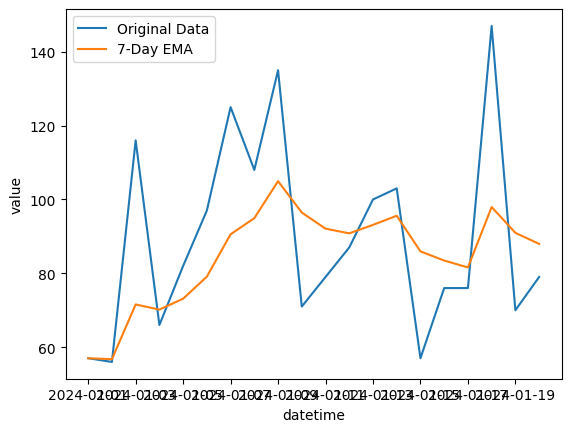

In [ ]:
# 이동평균 미니퀘스트 2번

df["EMA_7"] = df["value"].ewm(span=7, adjust=False).mean()

sns.lineplot(x="datetime", y="value", data=df, label="Original Data")
sns.lineplot(x="datetime", y="EMA_7", data=df, label="7-Day EMA")

plt.show()

In [ ]:
# 이동평균 미니퀘스트 3번

df["diff_rate"] = (df["SMA_7"] - df["value"]) / df["SMA_7"]

volatile_days = df[df["diff_rate"].abs() >= 0.2]

print(volatile_days.head())

            value       SMA_7       EMA_7  diff_rate
datetime                                            
2024-01-07    125   85.571429   90.572510  -0.460768
2024-01-09    135  104.142857  104.947037  -0.296296
2024-01-10     71   97.714286   96.460278   0.273392
2024-01-11     79   99.571429   92.095208   0.206600
2024-01-15     57   90.285714   85.940281   0.368671


In [ ]:
# 금융 데이터 미니퀘스트 1번

# 샘플 금융 데이터 생성
data = {
    'Date': pd.date_range(start='2024-01-01', periods=10, freq='D'),
    'Open': [100, 102, 105, 103, 108, 107, 110, 112, 115, 118],
    'High': [102, 106, 108, 107, 110, 109, 112, 115, 117, 120],
    'Low': [98, 100, 103, 101, 106, 105, 108, 110, 113, 116],
    'Close': [101, 104, 106, 105, 109, 108, 111, 113, 116, 119],
    'Volume': [1000, 1200, 1500, 1300, 1600, 1400, 1700, 1800, 1900, 2000]
}
df = pd.DataFrame(data)

print(df.shape[0])
print(df.shape[1])

print(df.dtypes)

10
6
Date      datetime64[ns]
Open               int64
High               int64
Low                int64
Close              int64
Volume             int64
dtype: object


In [ ]:
# 금융 데이터 미니퀘스트 2번

# 샘플 금융 데이터 생성
data = {
    'Date': pd.date_range(start='2024-01-01', periods=10, freq='D'),
    'Close': [101, 104, 106, 105, 109, 108, 111, 113, 116, 119]
}

df = pd.DataFrame(data)

df['SMA_5'] = df["Close"].rolling(window=5).mean()
df["EMA_5"] = df["Close"].ewm(span=5, adjust=False).mean()

print(df.head())

        Date  Close  SMA_5       EMA_5
0 2024-01-01    101    NaN  101.000000
1 2024-01-02    104    NaN  102.000000
2 2024-01-03    106    NaN  103.333333
3 2024-01-04    105    NaN  103.888889
4 2024-01-05    109  105.0  105.592593


In [ ]:
# 금융 데이터 미니퀘스트 3번

# 샘플 금융 데이터 생성 (30일치)
date_rng = pd.date_range(start='2024-01-01', periods=30, freq='D')
close_prices = np.random.uniform(100, 200, size=len(date_rng))  # 100~200 사이의 랜덤 종가 생성

df = pd.DataFrame({"Date": date_rng, "Close": close_prices})

df.set_index("Date", inplace=True)

weekly_mean = df["Close"].resample("7D").mean()

weekly_volatility = df["Close"].resample("7D").std()

print(weekly_mean)
print(weekly_volatility)


Date
2024-01-01    141.783627
2024-01-08    131.765867
2024-01-15    132.212794
2024-01-22    157.047626
2024-01-29    155.532799
Freq: 7D, Name: Close, dtype: float64
Date
2024-01-01    25.942653
2024-01-08    22.718218
2024-01-15    33.104104
2024-01-22    28.879177
2024-01-29    43.144351
Freq: 7D, Name: Close, dtype: float64


In [ ]:
# 정규분포 미니퀘스트 1번

np.random.seed(42)

# 평균 60, 표준 편차 15인 정규 분포에서 500개의 난수 생성
data = np.random.normal(loc=60, scale=15, size=500)

print(data[:5])

[67.4507123  57.92603548 69.71532807 82.84544785 56.48769938]


In [ ]:
# 정규분포 미니퀘스트 2번

x_value = 65
pdf_value = stats.norm.pdf(x_value, loc=50, scale=10)

print(f"f({x_value}) = {pdf_value}")



f(65) = 0.012951759566589175


In [ ]:
# 정규분포 미니퀘스트 3번

x_value = 80
cdf_value = stats.norm.cdf(x_value, loc=70, scale=8)

print(f"P(X ≤ {x_value}) = {cdf_value:.4f}")

quantile_90 = stats.norm.ppf(0.95, loc=50, scale=10)

print(quantile_90)

P(X ≤ 80) = 0.8944
66.44853626951472


In [ ]:
# 기술 통계 미니퀘스트 1번

# 샘플 데이터 생성
np.random.seed(42)
data = np.random.normal(loc=50, scale=10, size=100)  # 평균 50, 표준편차 10인 정규 분포 데이터 생성
df = pd.DataFrame(data, columns=["value"])  # 데이터프레임 생성

mean_value = np.mean(df["value"])
median_value = np.median(df["value"])

print(mean_value - median_value)

0.2310977438562034


In [ ]:
# 기술 통계 미니퀘스트 2번

# 샘플 데이터 생성
np.random.seed(42)
data = np.random.normal(loc=50, scale=10, size=100)  # 평균 50, 표준편차 10인 정규 분포 데이터 생성
df = pd.DataFrame(data, columns=["value"])  # 데이터프레임 생성

mean_value = np.mean(df["value"])


q1 = np.percentile(df["value"], 25)
q3 = np.percentile(df["value"], 75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = df[(df["value"] >= lower_bound) & (df["value"] <= upper_bound)]

outlier_mean_value = np.mean(outliers["value"])

print(mean_value)
print(outlier_mean_value)


48.96153482605907
49.215665996432364


In [ ]:
# 기술 통계 미니퀘스트 3번

# 샘플 데이터 생성
np.random.seed(42)
data = np.random.normal(loc=50, scale=10, size=100)  # 평균 50, 표준편차 10인 정규 분포 데이터 생성
df = pd.DataFrame(data, columns=["value"])  # 데이터프레임 생성

skewness = stats.skew(df["value"])
kurtosis = stats.kurtosis(df["value"])

print(skewness)
print(kurtosis)

-0.17526772024434067
-0.15540470774207948


In [ ]:
# 가설검정 미니퀘스트 1번

# 샘플 데이터 생성
np.random.seed(42)
sample_data = np.random.normal(loc=50, scale=5, size=30)  # 평균 50, 표준편차 5인 데이터 30개 생성

t_stat, p_value = stats.ttest_1samp(sample_data, popmean=52)

alpha = 0.05

if p_value < alpha:
    print("유의미한 차이가 있다.")
else:
    print("유의미한 차이가 없다.")


유의미한 차이가 있다.


In [ ]:
# 가설검정 미니퀘스트 2번

# 관측된 데이터 (Observed)
observed = np.array([50, 60, 90])

# 기대값 (Expected)
expected = np.array([66, 66, 66]) * (observed.sum() / np.sum([66, 66, 66]))

chi_stat, p_value = stats.chisquare(f_obs=observed, f_exp=expected)

alpha = 0.05

if p_value < alpha:
    print("유의미한 차이가 있다.")
else:
    print("유의미한 차이가 없다.")

유의미한 차이가 있다.


In [ ]:
# 가설검정 미니퀘스트 3번

# 샘플 데이터 생성
np.random.seed(42)
group_1 = np.random.normal(loc=50, scale=10, size=30)  # 평균 50, 표준편차 10
group_2 = np.random.normal(loc=55, scale=10, size=30)  # 평균 55, 표준편차 10
group_3 = np.random.normal(loc=60, scale=10, size=30)  # 평균 60, 표준편차 10

f_stat, p_value = stats.f_oneway(group_1, group_2, group_3)

alpha = 0.05

if p_value < alpha:
    print("평균은 유의미하게 다르다.")
else:
    print("유의미하다고 보기 어렵다.")

평균은 유의미하게 다르다.


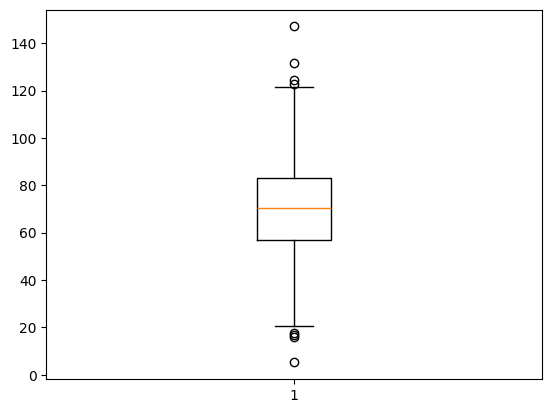

In [ ]:
# 통계적 시각화 미니퀘스트 1번

# 데이터 생성 (평균=70, 표준편차=20인 정규 분포 데이터 1000개)
np.random.seed(42)
data = np.random.normal(loc=70, scale=20, size=1000)

df = pd.DataFrame(data, columns=["value"])

plt.boxplot(df["value"])

plt.show()

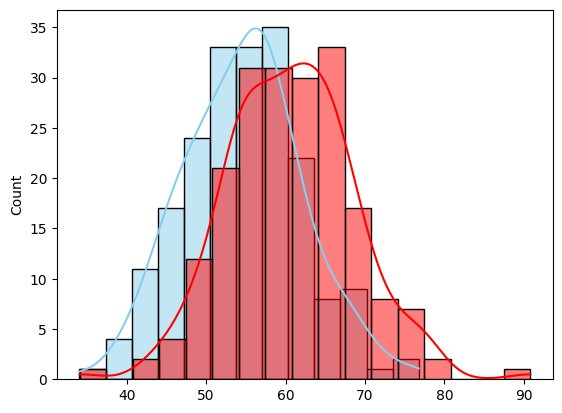

평균 차이는 유의미하다.


In [ ]:
# 통계적 시각화 미니퀘스트 2번

# 데이터 생성
np.random.seed(42)
group_A = np.random.normal(loc=55, scale=8, size=200)
group_B = np.random.normal(loc=60, scale=8, size=200)

sns.histplot(group_A,kde=True, color="skyblue")

sns.histplot(group_B,kde=True, color="red")

plt.show()


t_stat, p_value = stats.ttest_ind(group_A, group_B)

alpha = 0.05

if p_value < alpha:
    print("평균 차이는 유의미하다.")
else:
    print("평균 차이는 유의미하지 않다.")

차이는 유의미하다.


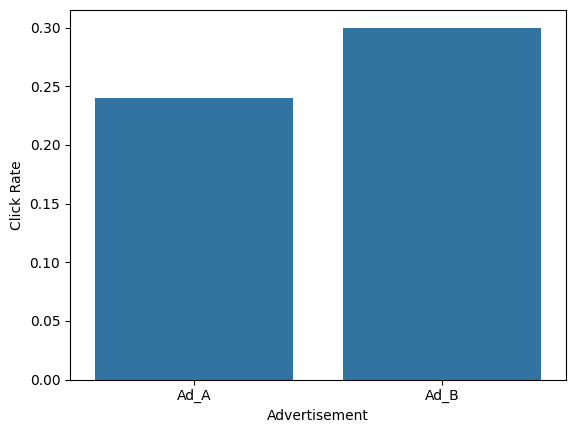

In [ ]:
# 통계적 시각화 미니퀘스트 3번

# 데이터 생성 (광고 A와 B의 클릭 여부)
observed_data = pd.DataFrame({
    "Ad_A": [120, 380],  # 광고 A 클릭(120명) vs 미클릭(380명)
    "Ad_B": [150, 350]   # 광고 B 클릭(150명) vs 미클릭(350명)
}, index=["Click", "No Click"])

chi2, p_value, dof, expected = chi2_contingency(observed_data)

alpha = 0.05

if p_value < alpha:
    print("차이는 유의미하다.")
else:
    print("차이는 유의미하지 않다.")

click_rate = pd.DataFrame({"Advertisement": ["Ad_A", "Ad_B"],"Click Rate": [120 / (120 + 380),150 / (150 + 350)]})

sns.barplot(data=click_rate,x="Advertisement",y="Click Rate")

plt.show()

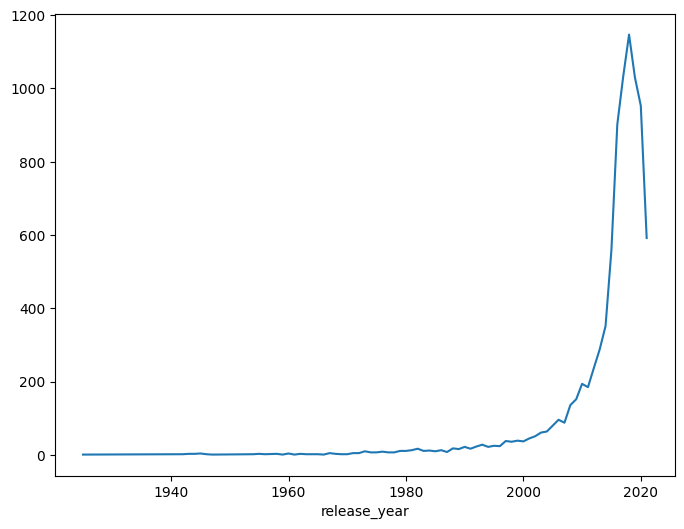

In [ ]:
# 위클리 챌린지 3-1
# 시계열 데이터를 입수하여 시각화 하세요

df = pd.read_csv("/KTB-eric-AI/week3/netflix_titles.csv")

yearly = df.groupby(df["release_year"]).size()

plt.figure(figsize=(8,6))

sns.lineplot(x=yearly.index,y=yearly.values)

plt.show()